# Quantum approximate optimization algorithm

## Setup



In [9]:
import matplotlib
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator

Initialize your problem by creating a graph with $n=5$ nodes.



Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.0319680319680318
       x: [ 3.492e+00  1.901e+00  2.615e+00  4.759e+00]
    nfev: 24
   maxcv: 0.0


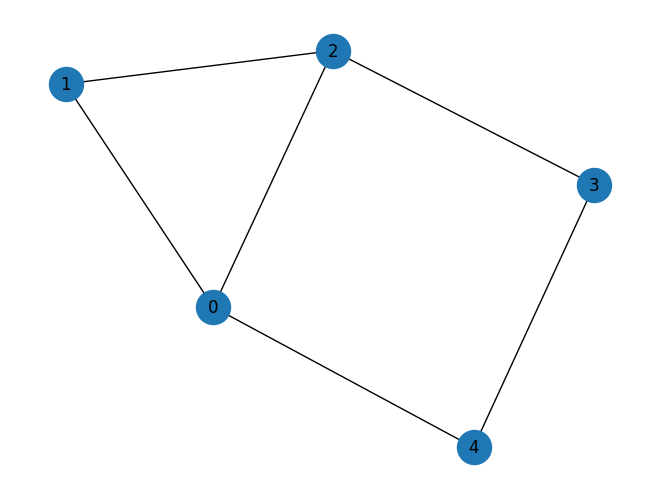

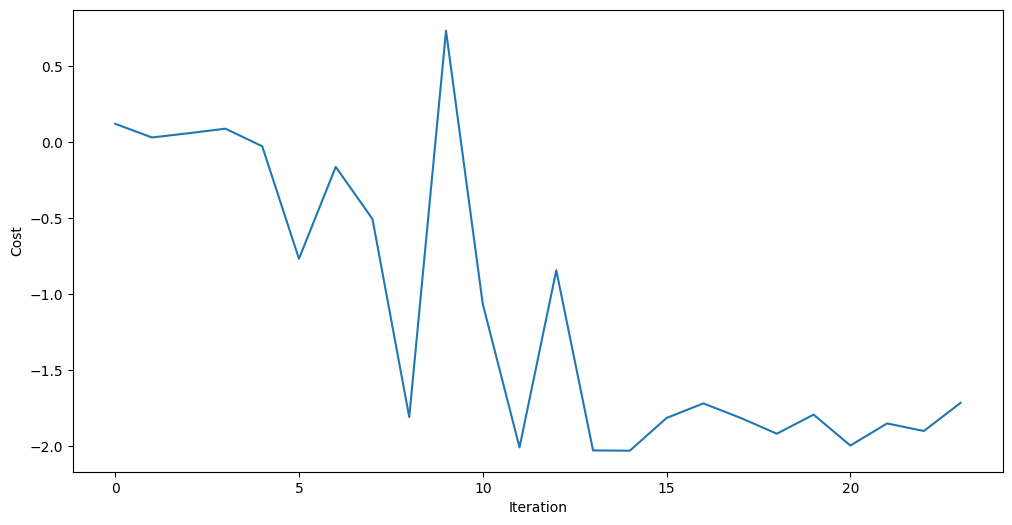

{5: 0.1514, 20: 0.0796, 22: 0.0829, 11: 0.0822, 26: 0.1426, 13: 0.0303, 9: 0.0767, 12: 0.0272, 14: 0.0282, 10: 0.031, 30: 0.0058, 18: 0.027, 31: 0.0033, 21: 0.0327, 19: 0.0301, 23: 0.0046, 25: 0.0037, 29: 0.04, 2: 0.0361, 7: 0.0097, 17: 0.0244, 27: 0.0056, 24: 0.0082, 15: 0.005, 8: 0.004, 1: 0.0075, 4: 0.005, 28: 0.0031, 3: 0.0026, 16: 0.0043, 6: 0.0027, 0: 0.0025}
Result bitstring: [1, 0, 1, 0, 0]


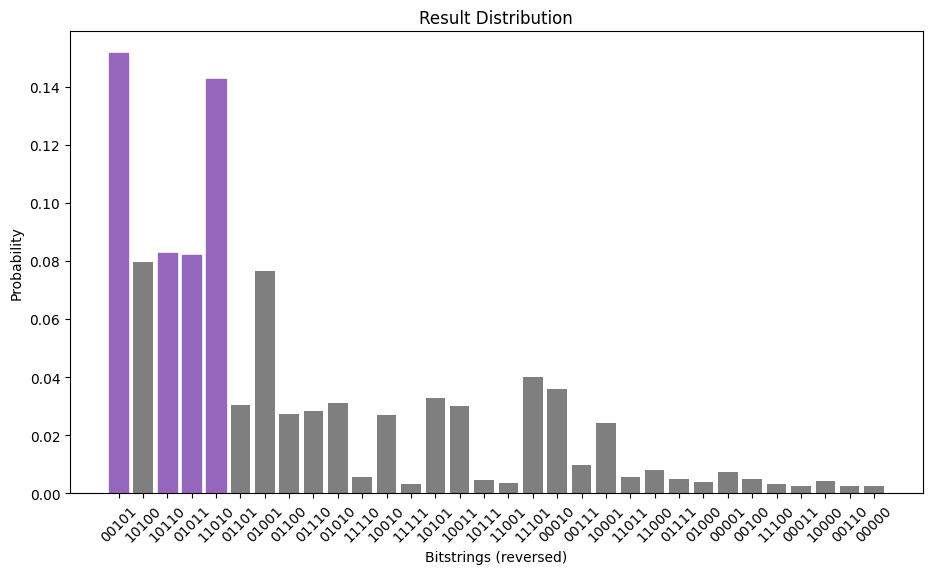

The value of the cut is: 4


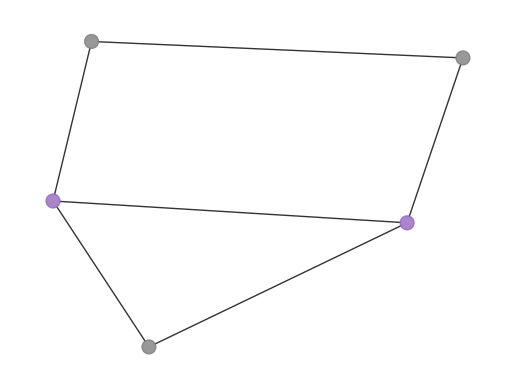

In [10]:
n = 5
# The problem to solv - the graph!
graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [
    (0, 1, 1.0),
    (0, 2, 1.0),
    (0, 4, 1.0),
    (1, 2, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

# Build the circuit - automatic!
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw("mpl")

circuit.parameters

# Simulator of the circuit
aer_sim = AerSimulator()
backend = aer_sim
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

objective_func_vals = []  # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )


plot_result(graph, most_likely_bitstring)

def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(
        list(graph.nodes())
    ), "The length of x must coincide with the number of nodes in the graph."
    return sum(
        x[u] * (1 - x[v]) + x[v] * (1 - x[u])
        for u, v in list(graph.edge_list())
    )


cut_value = evaluate_sample(most_likely_bitstring, graph)
print("The value of the cut is:", cut_value)

In [121]:
def plot_bar_flops(tree, output_file="cbar_flops.png"):
    min_step_flops = float('inf')
    max_step_flops = 0

    # Iterate over all intermediate nodes (keys in tree.info)
    for node in tree.info:
        # tree.get_flops(node) returns the cost to form that specific node
        flops = tree.get_flops(node)
        if flops > max_step_flops:
            max_step_flops = flops
        if flops < min_step_flops and flops != 0:
            min_step_flops = flops

    print(f"Max single-step FLOPs: {max_step_flops:.2e}")
    min_val = min_step_flops       # Example: 10^0
    max_val = max_step_flops   # Example: 10^4
    cmap_name = 'YlOrRd' # Yellow-Orange-Red (same as your FLOPS scale)

    # 2. Setup the Figure and Axis
    # Aspect ratio (width, height) controls the "bar" shape
    vmin_log = np.log10(min_val)
    vmax_log = np.log10(max_val)

    # 3. Setup Figure
    fig, ax = plt.subplots(figsize=(1, 6))
    fig.subplots_adjust(right=0.25)

    # 4. Use LINEAR Normalize on the log values
    # This ensures nice, even ticks like 0.0, 1.0, 2.0
    norm = mpl.colors.Normalize(vmin=vmin_log, vmax=vmax_log)
    cmap = plt.get_cmap('YlOrRd')

    # 5. Create the Colorbar
    cb = mpl.colorbar.ColorbarBase(ax, 
                                cmap=cmap,
                                norm=norm,
                                orientation='vertical')

    # 6. Labeling to match the style
    #cb.set_label('log10[FLOPS]', size=12, labelpad=10) # The label indicates it's log data
    cb.ax.tick_params(labelsize=10) # Adjust tick size
    fig.savefig(output_file, bbox_inches='tight', dpi=300, transparent=True)
    plt.close(fig)



def plot_bar_size(tree, output_file="cbar_size.png"):
    min_step_size = float('inf')
    max_step_size = 0

    # Iterate over all intermediate nodes
    for node in tree.info:
        # tree.get_size(node) returns the number of elements in the tensor
        size = tree.get_size(node)
        
        if size > max_step_size:
            max_step_size = size
        if size < min_step_size and size > 0:
            min_step_size = size


    # 2. Setup Plotting Variables
    min_val = min_step_size
    max_val = max_step_size

    # Use log2 for memory/size (standard convention)
    vmin_log = np.log2(min_val)
    vmax_log = np.log2(max_val)

    # 3. Setup Figure
    fig, ax = plt.subplots(figsize=(1, 6))
    fig.subplots_adjust(right=0.25)

    # 4. Use LINEAR Normalize on the log2 values
    norm = mpl.colors.Normalize(vmin=vmin_log, vmax=vmax_log)

    # Use 'YlGnBu' (Yellow-Green-Blue) to match standard Cotengra size plots
    cmap = plt.get_cmap('YlGnBu') 

    # 5. Create the Colorbar
    cb = mpl.colorbar.ColorbarBase(ax, 
                                cmap=cmap,
                                norm=norm,
                                orientation='vertical')

    # 6. Labeling
    # labeling it log2[SIZE] to be explicit
    # cb.set_label('log2[SIZE]', size=12, labelpad=10) 
    cb.ax.tick_params(labelsize=10)

    fig.savefig(output_file, bbox_inches='tight', dpi=300, transparent=True)
    plt.close(fig)

def plot_and_save_tree_with_separate_bars(tree, output_file_main="main_plot.png", output_file_flops="cbar_flops.png", output_file_size="cbar_size.png"): 
    plot_bar_flops(tree, output_file_flops)
    plot_bar_size(tree, output_file_size)

    fig, ax = tree.plot_tent(order=True, colorbars=False, edge_colormap="YlGnBu", node_colormap="YlOrRd")
    fig.savefig(output_file_main, bbox_inches='tight', dpi=300, transparent=True)

    plt.close(fig)


ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...
-> Converted! Network has 44 tensors and 56 indices.

[Step 3] Attempting Naive Contraction...
NAIVE = 


 <ContractionTree(N=44, F=3.25, C=4.62, S=6.00, P=8.04)> 

 1784


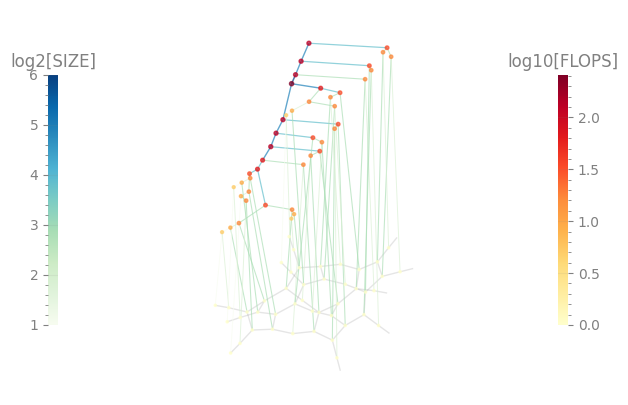

Max single-step FLOPs: 2.56e+02

[Step 4] Optimizing for UPMEM (Limit: 0.0003 MB)...


F=3.58 C=5.01 S=4.00 P=7.99 $=4.00: 100%|██████████| 32/32 [00:00<00:00, 156.23it/s]


UPMEM = 


 <ContractionTree(N=44, F=3.58, C=5.01, S=4.00, P=7.99, $=4.00)> 

 3792
-> UPMEM Max Memory: 2^4.0 elements
-> Total Slices (DPU Tasks): 4
-> Calculation Overhead: 2.13x


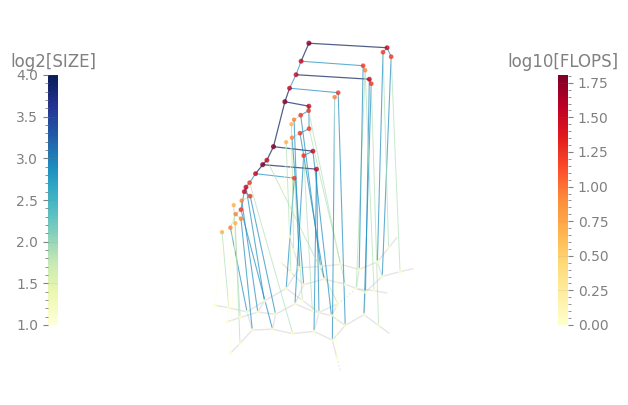

Max single-step FLOPs: 6.40e+01


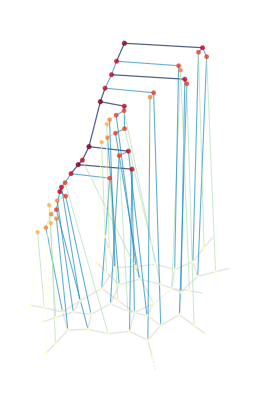

In [109]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices
    print(f"-> Converted! Network has {n_tensors} tensors and {n_indices} indices.")

    # -----------------------------------------------------
    # STEP 2: GEOMETRY VIEW (Physics)
    # -----------------------------------------------------
    G_tn = nx.Graph()
    tensors = [t for t in tn]
    for i in range(len(tensors)):
        G_tn.add_node(i)
        for j in range(i + 1, len(tensors)):
            if set(tensors[i].inds).intersection(tensors[j].inds):
                G_tn.add_edge(i, j)

    #plt.figure(figsize=(6, 6))
    #pos = nx.spring_layout(G_tn, seed=42, k=0.15, iterations=50)
    #nx.draw(G_tn, pos, node_size=30, node_color='#00d2ff', edge_color='#cccccc', width=0.5)
    #plt.title("Tensor Network Geometry\n(Transpiled Circuit Structure)")
    #plt.show()

    # -----------------------------------------------------
    # STEP 3: NAIVE SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3] Attempting Naive Contraction...")
    opt_naive = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_naive = opt_naive.search(inputs, output, size_dict)
        max_mem_naive = math.log2(tree_naive.max_size())
        print("="*60)
        print("NAIVE = \n\n\n", tree_naive, "\n\n", tree_naive.total_flops())
        print("="*60)
        
        #fig, ax = plt.subplots(figsize=(6, 6))
        # --- SAFE PLOT: No edge_alpha ---
        #tree_naive.plot_ring(ax=ax)
        tree_naive.plot_tent(order=True, colorbars=True)
        #tree_naive.plot_flat()
        #ax.set_title(f"Naive Path\nMem: 2^{max_mem_naive:.1f} | Slices: 1")
        #plt.show()
        max_step_flops = 0

        # Iterate over all intermediate nodes (keys in tree.info)
        for node in tree_naive.info:
            # tree.get_flops(node) returns the cost to form that specific node
            flops = tree_naive.get_flops(node)
            if flops > max_step_flops:
                max_step_flops = flops

        print(f"Max single-step FLOPs: {max_step_flops:.2e}")
    except Exception as e:
        print(f"Naive search failed: {e}")

    # -----------------------------------------------------
    # STEP 4: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmem = opt_upmem.search(inputs, output, size_dict)
    print("="*60)
    print("UPMEM = \n\n\n", tree_upmem, "\n\n", tree_upmem.total_flops())
    print("="*60)
    
    max_mem_upmem = math.log2(tree_upmem.max_size())
    slices = tree_upmem.nslices
    overhead = tree_upmem.total_flops() / tree_naive.total_flops()
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmem:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slices}")
    print(f"-> Calculation Overhead: {overhead:.2f}x")

    #fig, ax = plt.subplots(figsize=(6, 6))
    # --- SAFE PLOT: No edge_alpha ---
    #tree_upmem.plot_ring(ax=ax)
    tree_upmem.plot_tent(order=True, colorbars=True, edge_colormap="YlGnBu", node_colormap="YlOrRd")
    #tree_upmem.plot_tent(order=True, colorbars=False)
    #tree_upmem.plot_flat(show_sliced=True)
    #tree_upmem.plot_flat(show_sliced=False)
    #tree_upmem.plot_circuit()
    #tree_upmem.plot_rubberband()
    '''tree_upmem.plot_rubberband(
        raw_edge_alpha=0.0,
        edge_colormap="Greens",
        node_colormap="Greens",
        edge_scale=2,
        node_scale=0.5,
        colorbars=False,
        tree_root_height=-1.0,
        figsize=(10, 10),
    )
    
    tree_upmem.plot_tent(
        raw_edge_alpha=0.0,
        edge_colormap="Greens",
        node_colormap="Greens",
        edge_scale=2,
        node_scale=0.5,
        colorbars=False,
        tree_root_height=-1.0,
        figsize=(10, 10),
    )'''

    plot_and_save_tree_with_separate_bars(tree_upmem,"a.svg")

# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=0.0003)


ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...

[Step 3] Attempting Naive Contraction...
Max single-step FLOPs: 1.64e+04


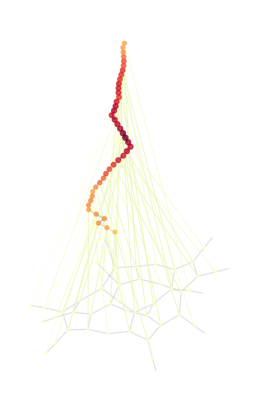


[Step 4] Optimizing for UPMEM (Limit: 0.0003 MB)...


F=3.57 C=5.00 S=4.00 P=8.00 $=4.00: 100%|██████████| 32/32 [00:00<00:00, 83.70it/s] 


Slices: 	 4
Max single-step FLOPs: 6.40e+01


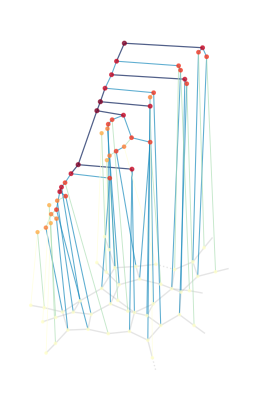

In [122]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices

    # -----------------------------------------------------
    # STEP 3: NAIVE SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3] Attempting Naive Contraction...")
    opt_naive = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_naive = opt_naive.search(inputs, output, size_dict)
        plot_and_save_tree_with_separate_bars(tree_naive, "naive_small.svg", "naive_small_bar_flops.svg", "naive_small_bar_size.svg")
    except Exception as e:
        print(f"Naive search failed: {e}")

    # -----------------------------------------------------
    # STEP 4: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmem = opt_upmem.search(inputs, output, size_dict)
    print("Slices: \t", tree_upmem.nslices)

    plot_and_save_tree_with_separate_bars(tree_upmem, "upmem_small.svg", "upmem_small_bar_flops.svg", "upmem_small_bar_size.svg")

# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=0.0003)

In [41]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices
    print(f"-> Converted! Network has {n_tensors} tensors and {n_indices} indices.")

    # -----------------------------------------------------
    # STEP 2: GEOMETRY VIEW (Physics)
    # -----------------------------------------------------
    G_tn = nx.Graph()
    tensors = [t for t in tn]
    for i in range(len(tensors)):
        G_tn.add_node(i)
        for j in range(i + 1, len(tensors)):
            if set(tensors[i].inds).intersection(tensors[j].inds):
                G_tn.add_edge(i, j)

    #plt.figure(figsize=(6, 6))
    #pos = nx.spring_layout(G_tn, seed=42, k=0.15, iterations=50)
    #nx.draw(G_tn, pos, node_size=30, node_color='#00d2ff', edge_color='#cccccc', width=0.5)
    #plt.title("Tensor Network Geometry\n(Transpiled Circuit Structure)")
    #plt.show()

    # -----------------------------------------------------
    # STEP 3: NAIVE SIMULATION (Baseline)
    # -----------------------------------------------------
    print("\n[Step 3] Attempting Naive Contraction...")
    opt_naive = ctg.HyperOptimizer(methods=['greedy'], max_repeats=1, progbar=False)
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    try:
        tree_naive = opt_naive.search(inputs, output, size_dict)
        max_mem_naive = math.log2(tree_naive.max_size())
        
    except Exception as e:
        print(f"Naive search failed: {e}")

    # -----------------------------------------------------
    # STEP 4: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmem = opt_upmem.search(inputs, output, size_dict)
    
    max_mem_upmem = math.log2(tree_upmem.max_size())
    slices = tree_upmem.nslices
    overhead = tree_upmem.total_flops() / tree_upmem.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmem:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slices}")
    print(f"-> Calculation Overhead: {overhead:.2f}x")

    # 2. CALCULATE SHARED SCALES (The "One Ruler" Rule)
    # ---------------------------------------------------------
    # MEMORY (Height): Max size across BOTH trees
    max_size_log2 = max(math.log2(tree_naive.max_size()), math.log2(tree_upmem.max_size()))
    GLOBAL_YLIM = (0, max_size_log2 + 2)

    # COMPUTE (Color): Min/Max FLOPs across BOTH trees
    min_flops = min(math.log10(tree_naive.total_flops()), math.log10(tree_upmem.total_flops()))
    max_flops = max(math.log10(tree_naive.total_flops()), math.log10(tree_upmem.total_flops()))
    GLOBAL_CLIM = (min_flops, max_flops)

    # 3. GENERATE THE PLOTS
    # ---------------------------------------------------------
    def save_plot(tree, filename):
        fig, ax = plt.subplots(figsize=(5, 5))
        tree.plot_tent(ax=ax, order=True, colorbars=False)
        
        # FORCE SHARED SCALES
        ax.set_ylim(GLOBAL_YLIM)           # Force Height
        for c in ax.collections: 
            c.set_clim(GLOBAL_CLIM)        # Force Color
            
        ax.set_axis_off()
        fig.savefig(filename, dpi=300, transparent=True, bbox_inches='tight', pad_inches=0)
        plt.close()

    save_plot(tree_naive, "poster_naive.png")
    save_plot(tree_upmem, "poster_optimized.png")

    # 4. SCALE GENERATOR (Separate Files)
    # ---------------------------------------------------------
    # A. COMPUTE SCALE (The Colorbar)
    fig, ax = plt.subplots(figsize=(0.5, 6))
    norm = mpl.colors.Normalize(vmin=GLOBAL_CLIM[0], vmax=GLOBAL_CLIM[1])
    cb = mpl.colorbar.ColorbarBase(ax, cmap=plt.get_cmap('RdYlBu_r'), norm=norm)
    cb.set_label('Compute ($log_{10}$ FLOPs)', color='white', fontsize=14)
    cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')
    cb.outline.set_visible(False)
    fig.savefig("scale_compute.png", dpi=300, transparent=True, bbox_inches='tight')
    plt.close()

    # B. MEMORY SCALE (The Vertical Ruler)
    fig, ax = plt.subplots(figsize=(0.8, 6))
    ax.set_ylim(GLOBAL_YLIM) # Must match the plots!
    ax.spines['left'].set_color('white')
    ax.spines['left'].set_linewidth(2)
    for s in ['top','right','bottom']: ax.spines[s].set_visible(False)
    ax.set_xticks([])
    ax.tick_params(axis='y', colors='white', labelsize=12)
    ax.set_ylabel("Memory ($log_2$ Size)", color='white', fontsize=14)
    fig.savefig("scale_memory.png", dpi=300, transparent=True, bbox_inches='tight')
    plt.close()

    print("DONE!")
    print("1. poster_naive.png")
    print("2. poster_optimized.png")
    print("3. poster_scale_color.png (Valid for BOTH plots)")
# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=0.0003)


ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...
-> Converted! Network has 44 tensors and 56 indices.

[Step 3] Attempting Naive Contraction...

[Step 4] Optimizing for UPMEM (Limit: 0.0003 MB)...


F=4.07 C=5.53 S=4.00 P=7.91 $=16.00: 100%|██████████| 32/32 [00:00<00:00, 133.67it/s]


-> UPMEM Max Memory: 2^4.0 elements
-> Total Slices (DPU Tasks): 16
-> Calculation Overhead: 1.00x
DONE!
1. poster_naive.png
2. poster_optimized.png
3. poster_scale_color.png (Valid for BOTH plots)



VISUALIZING: Physical Hardware Flow


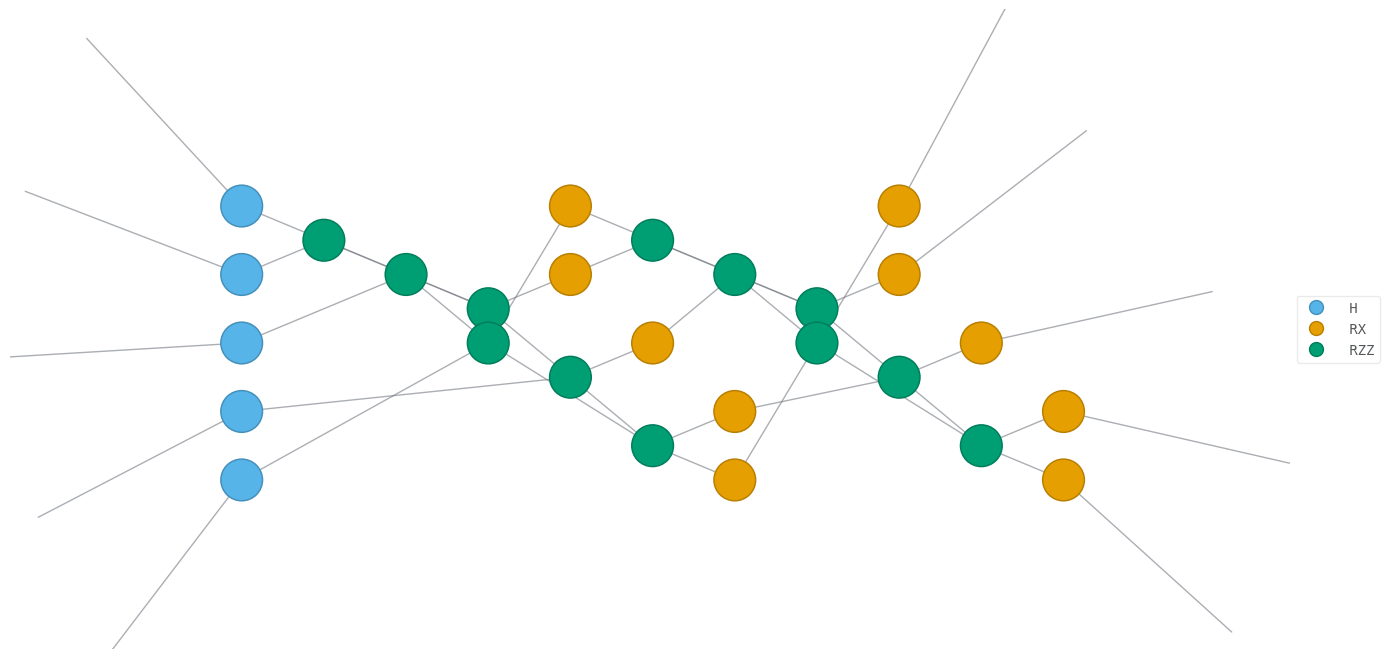

In [130]:
import matplotlib.pyplot as plt
import numpy as np
import quimb.tensor as qtn
from qiskit import QuantumCircuit

def recursive_decompose(circ):
    """Recursively breaks down high-level blocks until we hit basis gates."""
    blockers = ['QAOA', 'PauliEvolution', 'EvolvedOps', 'definition']
    current_circ = circ
    for _ in range(5):
        if any(inst.operation.name in blockers for inst in current_circ.data):
            current_circ = current_circ.decompose()
        else:
            break
    return current_circ

def visualize_circuit_flow(qiskit_circ, title="Tensor Network Circuit Flow"):
    print(f"\n{'='*60}")
    print(f"VISUALIZING: {title}")
    print(f"{'='*60}")
    
    # 1. Decompose circuit
    decomp_circ = recursive_decompose(qiskit_circ)
    num_qubits = decomp_circ.num_qubits
    
    # Setup Layout Tracking
    qubit_x_positions = {q: 0.0 for q in range(num_qubits)}
    fixed_positions = {} 
    
    tn = qtn.TensorNetwork([])
    wire_frontier = {q: f"q{q}_0" for q in range(num_qubits)}
    wire_counters = {q: 0 for q in range(num_qubits)}
    
    gate_types_found = set()

    # 2. Build TN & Calculate Coordinates
    for i, instruction in enumerate(decomp_circ.data):
        name = instruction.operation.name
        if name in ['barrier', 'measure', 'reset']: continue

        # Get Qubits
        try:
            qubits = [decomp_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubits = [decomp_circ.qubits.index(q) for q in instruction.qubits]
            
        # --- CALCULATE COORDINATES ---
        current_max_x = max([qubit_x_positions[q] for q in qubits])
        gate_x = current_max_x + 1.2 
        gate_y = -sum(qubits) / len(qubits)
        
        for q in qubits:
            qubit_x_positions[q] = gate_x

        # --- BUILD TENSOR ---
        input_inds = [wire_frontier[q] for q in qubits]
        output_inds = []
        for q in qubits:
            wire_counters[q] += 1
            new_wire = f"q{q}_{wire_counters[q]}"
            output_inds.append(new_wire)
            wire_frontier[q] = new_wire
            
        tag_name = name.upper()
        gate_types_found.add(tag_name)
        
        # --- FIX IS HERE ---
        # 1. Create a Unique ID String
        unique_id = f"G{i}"
        
        # 2. Create Tensor with that ID in tags
        num_inds = len(input_inds) + len(output_inds)
        T = qtn.Tensor(
            data=np.zeros(tuple([2] * num_inds)), 
            inds=input_inds + output_inds, 
            # We add unique_id to tags so Quimb can find it
            tags={tag_name, unique_id} 
        )
        
        tn.add_tensor(T)
        
        # 3. Map the String ID (not the object) to the coordinates
        fixed_positions[unique_id] = (gate_x, gate_y)

    # -----------------------------------------------------
    # 3. DRAWING
    # -----------------------------------------------------
    color_map = {
        'H': '#f1c40f', 'RZZ': '#2ecc71', 'RX': '#e67e22', 
        'RZ': '#e74c3c', 'CX': '#3498db', 'X': '#34495e',
        'SX': '#1abc9c', 'U': '#9b59b6'
    }
    colors_to_use = {g: color_map.get(g, '#95a5a6') for g in gate_types_found}

    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Draw Background Lines
    '''max_x = max(qubit_x_positions.values()) + 1
    max_x = max_x * 0.1
    for q in range(num_qubits):
        ax.plot([0, max_x], [-q, -q], color='#d3d3d3', zorder=0, linewidth=1.0)
        ax.text(-0.5, -q, f"q{q}", va='center', ha='right', fontsize=14, fontweight='bold', color='#666666')'''

    tn.draw(
        ax=ax,
        color=colors_to_use,
        fix=fixed_positions, # Now contains Strings -> Coords
        show_tags=False,
        show_inds=False,
        node_size=1,
        node_outline_darkness=0.8,
        edge_alpha=0.6,
        legend=True
    )
    
    #ax.set_title(title, fontsize=16, y=1.05)
    ax.axis('off')
    
    # Set limits
    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.5, 0.5)
    
    fig.tight_layout()
    fig.savefig("tensor_nerwork_small.svg", dpi=300, transparent=True, bbox_inches='tight')
    plt.show()

# =========================================================
# RUN
# =========================================================

# 1. Logical Flow
#visualize_circuit_flow(circuit, "Logical QAOA (Time-Flow Layout)")

# 2. Physical Flow
visualize_circuit_flow(optimized_circuit, "Physical Hardware Flow")

In [6]:
import quimb.tensor as qtn
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterExpression

def recursive_decompose(circ):
    """
    Recursively breaks down high-level Qiskit blocks (QAOA, PauliEvolution)
    until we hit basis gates that Quimb understands.
    """
    # Gates we generally want to decompose to see the underlying logic
    blockers = ['QAOA', 'PauliEvolution', 'EvolvedOps', 'definition', 'ansatz']
    
    current_circ = circ
    # Try decomposing up to 10 layers deep to catch nested structures
    for _ in range(10):
        # If we see any "blocker" gates, decompose the whole circuit
        if any(inst.operation.name in blockers for inst in current_circ.data):
            try:
                current_circ = current_circ.decompose()
            except Exception:
                break # Stop if decomposition fails
        else:
            break # Stop if no blockers found
            
    return current_circ

def qiskit_to_quimb(qiskit_circ):
    """
    Converts a Qiskit QuantumCircuit into a Quimb Circuit object.
    
    Args:
        qiskit_circ (QuantumCircuit): The input Qiskit circuit.
        
    Returns:
        quimb.tensor.Circuit: A simulatable Quimb circuit.
    """
    # 1. Clean the circuit (Decompose high-level blocks)
    decomp_circ = recursive_decompose(qiskit_circ)
    
    # 2. Initialize an empty Quimb Circuit
    N = decomp_circ.num_qubits
    quimb_circ = qtn.Circuit(N)
    
    print(f"-> Converting {len(decomp_circ.data)} instructions to Quimb...")
    
    # 3. Iterate through Qiskit instructions
    for i, instruction in enumerate(decomp_circ.data):
        op = instruction.operation
        name = op.name.lower() # Quimb generally uses lowercase gate names
        raw_params = op.params
        
        # Skip non-unitary operations
        if name in ['barrier', 'measure', 'reset', 'snapshot']:
            continue
            
        # --- FIX 1: Robust Parameter Conversion ---
        # Convert Qiskit parameters/numpy types to pure Python floats
        # This prevents 'autoray' from detecting a 'qiskit' backend and crashing.
        clean_params = []
        for p in raw_params:
            try:
                if isinstance(p, ParameterExpression):
                    # If the parameter is bound (has a value), convert it
                    # If it is unbound (symbolic), this might fail, which is expected
                    val = float(p) 
                    clean_params.append(val)
                elif hasattr(p, 'item'):
                    # Handle numpy scalars
                    clean_params.append(p.item())
                else:
                    # Standard float/int
                    clean_params.append(float(p))
            except Exception:
                # If conversion fails (e.g. unbound parameter), use a dummy value (0.1)
                # just to allow the tensor network structure to be built and visualized.
                # WARN: This circuit won't give correct math results if used for calculation!
                # print(f"Warning: Could not convert parameter '{p}'. Using 0.1 placeholder.")
                clean_params.append(0.1)
                
        # --- FIX 2: Gate Name Translation ---
        # Map Qiskit names to Quimb names
        if name == 'cx': name = 'cnot'
        if name == 'u': name = 'u3' # Qiskit generic U is U3
        if name == 'p': name = 'phase'
        if name == 'rzz': name = 'rzz' # Explicitly supported by Quimb, but needs params
        
        # Get Qubit Indices (Robust to Qiskit versions)
        try:
            qubits = [decomp_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            # Fallback for older Qiskit versions
            qubits = [decomp_circ.qubits.index(q) for q in instruction.qubits]
            
        # 4. Apply to Quimb Circuit
        try:
            # Quimb's apply_gate signature: apply_gate(gate_name, *params, *qubit_indices)
            # FIX: Use 'tags' directly instead of 'gate_opts'
            quimb_circ.apply_gate(
                name, 
                *clean_params, 
                *qubits, 
                tags={name.upper()}
            )
            
        except Exception as e:
            # Fallback: Use matrix definition if named gate fails
            try:
                # print(f"  Attempting matrix fallback for '{name}'...")
                matrix = op.to_matrix()
                # Quimb needs the matrix as a numpy array
                if not isinstance(matrix, np.ndarray):
                    matrix = np.array(matrix)
                
                quimb_circ.apply_gate(
                    f'gate_{i}', 
                    matrix, 
                    *qubits,
                    tags={name.upper()}
                )
            except Exception as e2:
                print(f"Warning: Skipped unsupported gate '{name}' at index {i}. Error: {e}")

    print("-> Conversion Complete.")
    return quimb_circ

# Example Usage:
# if __name__ == "__main__":
#     # assuming 'circuit' is your Qiskit object
#     quimb_version = qiskit_to_quimb(circuit)
#     
#     # Verify it works by calculating amplitude of the zero state
#     print(f"Amplitude of |00...0>: {quimb_version.amplitude('0'*quimb_version.N)}")

-> Converting 33 instructions to Quimb...
-> Conversion Complete.


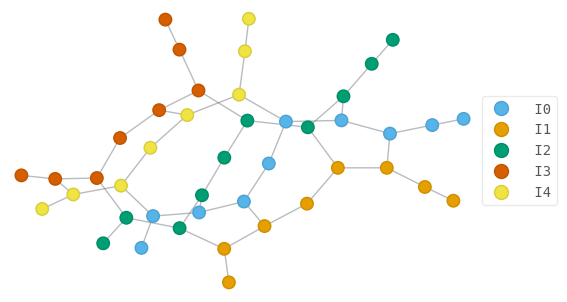

In [7]:
quimb_version = qiskit_to_quimb(circuit)
circ=quimb_version
tn = circ.amplitude_tn(simplify_sequence="")
tn.draw(tn.site_tags)

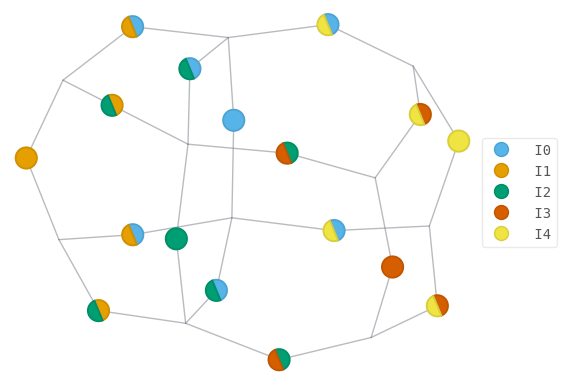

In [8]:
tn_fs = circ.amplitude_tn()
tn_fs.draw(tn.site_tags)


VERIFICATION: Calculating Amplitude for |10110>
-> Projecting output to bitstring...
-> Standardizing Network (Fixing Hyper-Edges)...

[UPMEM Sliced Result]
Optimizing for 0.0003 MB limit...
Distributing 2 slices to DPUs...
Optimizer Warning: tuple index out of range. Falling back to exact.

FINAL VERIFICATION REPORT
Qiskit Probability:   0.0967
UPMEM Sliced Prob:    0.0949


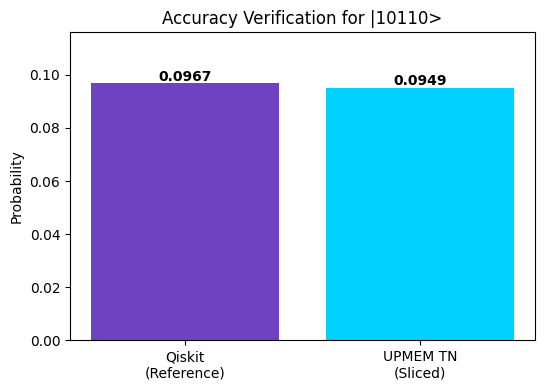

In [9]:
import numpy as np
import math
import cotengra as ctg
import quimb.tensor as qtn
import matplotlib.pyplot as plt

def verify_upmem_calculation(qiskit_circ, target_bitstring, expected_prob, memory_limit_mb=0.002):
    print(f"\n{'='*60}")
    print(f"VERIFICATION: Calculating Amplitude for |{target_bitstring}>")
    print(f"{'='*60}")
    
    # -----------------------------------------------------
    # 1. SETUP TENSOR NETWORK
    # -----------------------------------------------------
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # Robust Manual Gate Conversion
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        if name in ['barrier', 'measure', 'reset']: continue
        try:
            try:
                qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
            except AttributeError:
                qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except:
            pass

    # Extract clean list of tensors
    # This treats the network as a simple pile of tensors, ignoring graph complexity
    tensor_list = list(circ_quimb.psi)
    
    # -----------------------------------------------------
    # 2. PROJECTION (The List Method)
    # -----------------------------------------------------
    print("-> Projecting output to bitstring...")
    
    for i, bit_char in enumerate(target_bitstring):
        ind_name = f'k{i}' 
        bit_val = int(bit_char)
        
        # Create Projection Vector
        state_vector = np.zeros(2, dtype=complex)
        state_vector[bit_val] = 1.0
        T_proj = qtn.Tensor(data=state_vector, inds=(ind_name,))
        
        # Find the tensor connected to this wire
        target_idx = -1
        for idx, t in enumerate(tensor_list):
            if ind_name in t.inds:
                target_idx = idx
                break
        
        if target_idx != -1:
            # Contract locally (Pure Math)
            tensor_list[target_idx] = tensor_list[target_idx] @ T_proj
            
    # Rebuild Network
    tn = qtn.TensorNetwork(tensor_list)
    
    # -----------------------------------------------------
    # 3. STANDARDIZATION (The Fix for ValueError)
    # -----------------------------------------------------
    print("-> Standardizing Network (Fixing Hyper-Edges)...")
    # This inserts "Copy Tensors" so that every wire connects exactly 2 tensors.
    # This prevents the "index appears more than twice" error.
    '''AttributeErrortry:
        tn.expand_hyper_inds(inplace=True)
    except AttributeError:
        # Fallback for older quimb versions
        tn = tn.resolve_hyper_indices()'''
    
    # Check if network is already solved (Scalar)
    if tn.num_tensors <= 1:
        print("-> Network simplified to a scalar! (No Slicing needed)")
        final_amp = tn.contract() if tn.num_tensors == 1 else 1.0
        sliced_prob = abs(final_amp)**2
        print(f"Result: {sliced_prob:.4f}")
    else:
        # -----------------------------------------------------
        # 4. RUN UPMEM (SLICED) CONTRACTION
        # -----------------------------------------------------
        inputs = [tuple(t.inds) for t in tn]
        output = () 
        size_dict = {i: d for i, d in tn.ind_sizes().items()}
        
        limit_bytes = memory_limit_mb * 1024 * 1024
        # Safety clamp to prevent 0-byte limits
        if limit_bytes < 256: limit_bytes = 256
        target_log2 = math.log2(limit_bytes / 16) 
        
        print(f"\n[UPMEM Sliced Result]")
        print(f"Optimizing for {memory_limit_mb} MB limit...")
        
        opt_upmem = ctg.HyperOptimizer(
            max_repeats=32, 
            progbar=False,
            slicing_opts={'target_size': 2**target_log2} 
        )
        
        try:
            tree_upmem = opt_upmem.search(inputs, output, size_dict)
            
            # SIMULATE DPUs
            arrays = [t.data for t in tn]
            sliced_amp = 0.0 + 0.0j
            num_slices = tree_upmem.nslices
            
            print(f"Distributing {num_slices} slices to DPUs...")
            
            for i in range(num_slices):
                partial_result = tree_upmem.contract_slice(arrays, i=i)
                sliced_amp += partial_result
                
            sliced_prob = abs(sliced_amp)**2
            print(f"Summed Prob: {sliced_prob:.4f}")
            
        except Exception as e:
            print(f"Optimizer Warning: {e}. Falling back to exact.")
            final_amp = tn.contract()
            sliced_prob = abs(final_amp)**2

    # -----------------------------------------------------
    # 5. VISUALIZATION
    # -----------------------------------------------------
    print(f"\n{'='*60}")
    print("FINAL VERIFICATION REPORT")
    print(f"{'='*60}")
    print(f"Qiskit Probability:   {expected_prob:.4f}")
    print(f"UPMEM Sliced Prob:    {sliced_prob:.4f}")
    
    labels = ['Qiskit\n(Reference)', 'UPMEM TN\n(Sliced)']
    values = [expected_prob, sliced_prob]
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=['#6f42c1', '#00d2ff'])
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", 
                 ha='center', va='bottom', fontweight='bold')
                 
    plt.title(f"Accuracy Verification for |{target_bitstring}>")
    plt.ylabel("Probability")
    plt.ylim(0, max(values) * 1.2)
    plt.show()

# =========================================================
# RUN
# =========================================================
top_bitstring_str = list(final_distribution_bin.keys())[0] 
top_prob = list(final_distribution_bin.values())[0]

# Run Verification
verify_upmem_calculation(
    optimized_circuit, 
    target_bitstring=top_bitstring_str[::-1], 
    expected_prob=top_prob,
    memory_limit_mb=0.0003
)


VISUALIZING: Logical QAOA (Time-Flow Layout)


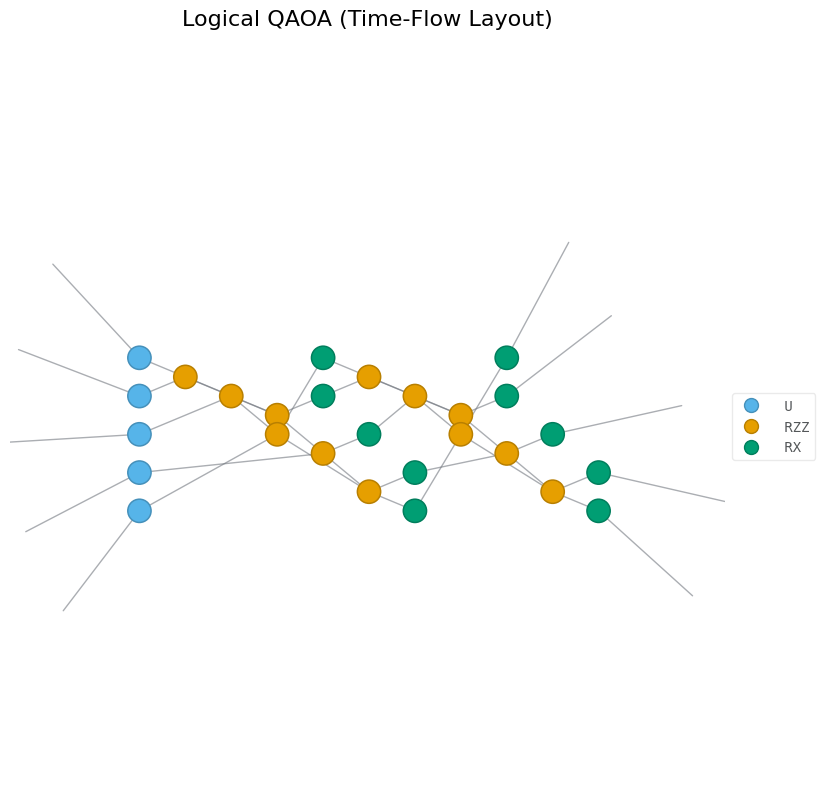


ANALYZING QISKIT CIRCUIT ON UPMEM
Converting Qiskit Circuit to Tensor Network...

[Step 4] Optimizing for UPMEM (Limit: 0.0003 MB)...


F=3.64 C=5.07 S=4.00 P=7.99 $=4.00: 100%|██████████| 32/32 [00:00<00:00, 63.99it/s] 


-> UPMEM Max Memory: 2^4.0 elements
-> Total Slices (DPU Tasks): 4
-> Calculation Overhead: 1.00x


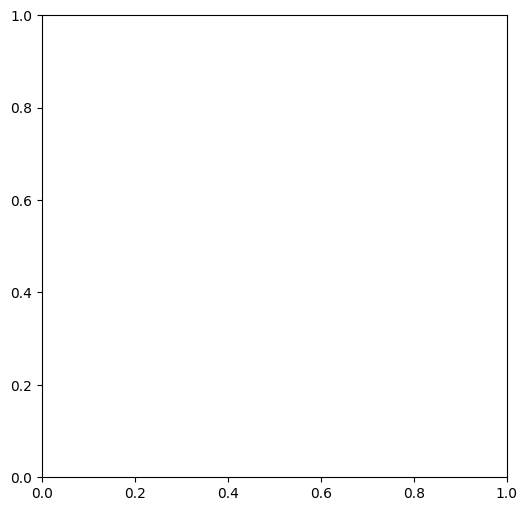

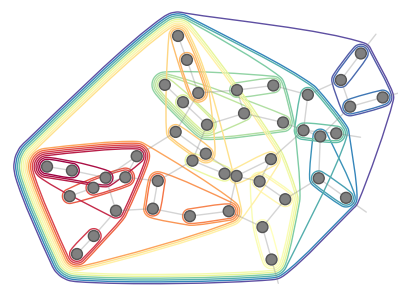

TypeError: plot_tree_rubberband() got an unexpected keyword argument 'edge_colormap'. Did you mean 'edge_color'?

In [ ]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

def analyze_qiskit_circuit_on_upmem(qiskit_circ, memory_limit_mb=0.01):
    print(f"\n{'='*60}\nANALYZING QISKIT CIRCUIT ON UPMEM\n{'='*60}")
    
    # -----------------------------------------------------
    # STEP 1: ROBUST CONVERSION (Manual Loop)
    # -----------------------------------------------------
    print("Converting Qiskit Circuit to Tensor Network...")
    
    # A. Initialize an empty Quimb Circuit
    N = qiskit_circ.num_qubits
    circ_quimb = qtn.Circuit(N)
    
    # B. Iterate through Qiskit instructions manually
    # This bypasses all version compatibility issues
    for instruction in qiskit_circ.data:
        op = instruction.operation
        name = op.name
        params = op.params
        
        # Handle qubit indices for different Qiskit versions
        try:
            qubit_indices = [qiskit_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubit_indices = [qiskit_circ.qubits.index(q) for q in instruction.qubits]

        # Skip non-unitary operations (measurement, barriers)
        if name in ['barrier', 'measure', 'reset']:
            continue
            
        # Apply gate to Quimb
        try:
            circ_quimb.apply_gate(name, *params, *qubit_indices)
        except Exception as e:
            # Fallback for complex gates: treat as generic unitary
            pass 

    tn = circ_quimb.psi
    
    n_tensors = tn.num_tensors
    n_indices = tn.num_indices

    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}

    # -----------------------------------------------------
    # STEP 4: UPMEM SLICED SIMULATION
    # -----------------------------------------------------
    limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    print(f"\n[Step 4] Optimizing for UPMEM (Limit: {memory_limit_mb} MB)...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    tree_upmem = opt_upmem.search(inputs, output, size_dict)
    
    max_mem_upmem = math.log2(tree_upmem.max_size())
    slices = tree_upmem.nslices
    overhead = tree_upmem.total_flops() / tree_upmem.contract_stats()['flops']
    
    print(f"-> UPMEM Max Memory: 2^{max_mem_upmem:.1f} elements")
    print(f"-> Total Slices (DPU Tasks): {slices}")
    print(f"-> Calculation Overhead: {overhead:.2f}x")

    fig, ax = plt.subplots(figsize=(6, 6))
    # --- SAFE PLOT: No edge_alpha ---
    tree_upmem.plot_rubberband()
    tree_upmem.plot_rubberband(
        edge_alpha=0.0,
        edge_colormap="Greens",
        node_colormap="Greens",
        edge_scale=2,
        node_scale=0.5,
        colorbars=False,
        tree_root_height=-1.0,
        figsize=(10, 10),
    )
    tree_upmem.plot_tent(
        raw_edge_alpha=0.0,
        edge_colormap="Greens",
        node_colormap="Greens",
        edge_scale=2,
        node_scale=0.5,
        colorbars=False,
        tree_root_height=-1.0,
        figsize=(10, 10),
    )

    ax.set_title(f"UPMEM Sliced Path\nMem: 2^{max_mem_upmem:.1f} | Slices: {slices}")
    plt.show()


def recursive_decompose(circ):
    """Recursively breaks down high-level blocks until we hit basis gates."""
    blockers = ['QAOA', 'PauliEvolution', 'EvolvedOps', 'definition']
    current_circ = circ
    for _ in range(5):
        if any(inst.operation.name in blockers for inst in current_circ.data):
            current_circ = current_circ.decompose()
        else:
            break
    return current_circ

def visualize_circuit_flow(qiskit_circ, title="Tensor Network Circuit Flow"):
    print(f"\n{'='*60}")
    print(f"VISUALIZING: {title}")
    print(f"{'='*60}")
    
    # 1. Decompose circuit
    decomp_circ = recursive_decompose(qiskit_circ)
    num_qubits = decomp_circ.num_qubits
    
    # Setup Layout Tracking
    qubit_x_positions = {q: 0.0 for q in range(num_qubits)}
    fixed_positions = {} 
    
    tn = qtn.TensorNetwork([])
    wire_frontier = {q: f"q{q}_0" for q in range(num_qubits)}
    wire_counters = {q: 0 for q in range(num_qubits)}
    
    gate_types_found = set()

    # 2. Build TN & Calculate Coordinates
    for i, instruction in enumerate(decomp_circ.data):
        name = instruction.operation.name
        if name in ['barrier', 'measure', 'reset']: continue

        # Get Qubits
        try:
            qubits = [decomp_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubits = [decomp_circ.qubits.index(q) for q in instruction.qubits]
            
        # --- CALCULATE COORDINATES ---
        current_max_x = max([qubit_x_positions[q] for q in qubits])
        gate_x = current_max_x + 1.2 
        gate_y = -sum(qubits) / len(qubits)
        
        for q in qubits:
            qubit_x_positions[q] = gate_x

        # --- BUILD TENSOR ---
        input_inds = [wire_frontier[q] for q in qubits]
        output_inds = []
        for q in qubits:
            wire_counters[q] += 1
            new_wire = f"q{q}_{wire_counters[q]}"
            output_inds.append(new_wire)
            wire_frontier[q] = new_wire
            
        tag_name = name.upper()
        gate_types_found.add(tag_name)
        
        # --- FIX IS HERE ---
        # 1. Create a Unique ID String
        unique_id = f"G{i}"
        
        # 2. Create Tensor with that ID in tags
        num_inds = len(input_inds) + len(output_inds)
        T = qtn.Tensor(
            data=np.zeros(tuple([2] * num_inds)), 
            inds=input_inds + output_inds, 
            # We add unique_id to tags so Quimb can find it
            tags={tag_name, unique_id} 
        )
        
        tn.add_tensor(T)
        
        # 3. Map the String ID (not the object) to the coordinates
        fixed_positions[unique_id] = (gate_x, gate_y)

    # -----------------------------------------------------
    # 3. DRAWING
    # -----------------------------------------------------
    color_map = {
        'H': '#f1c40f', 'RZZ': '#2ecc71', 'RX': '#e67e22', 
        'RZ': '#e74c3c', 'CX': '#3498db', 'X': '#34495e',
        'SX': '#1abc9c', 'U': '#9b59b6'
    }
    colors_to_use = {g: color_map.get(g, '#95a5a6') for g in gate_types_found}

    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Draw Background Lines
    '''max_x = max(qubit_x_positions.values()) + 1
    max_x = max_x * 0.1
    for q in range(num_qubits):
        ax.plot([0, max_x], [-q, -q], color='#d3d3d3', zorder=0, linewidth=1.0)
        ax.text(-0.5, -q, f"q{q}", va='center', ha='right', fontsize=14, fontweight='bold', color='#666666')'''

    tn.draw(
        ax=ax,
        color=colors_to_use,
        fix=fixed_positions, # Now contains Strings -> Coords
        show_tags=False,
        show_inds=False,
        node_size=1,
        node_outline_darkness=0.8,
        edge_alpha=0.6,
        legend=True
    )
    
    ax.set_title(title, fontsize=16, y=1.05)
    ax.axis('off')
    
    # Set limits
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    
    plt.tight_layout()
    plt.show()

# =========================================================
# RUN
# =========================================================

# 1. Logical Flow
visualize_circuit_flow(circuit, "Logical QAOA (Time-Flow Layout)")

# EXECUTE
analyze_qiskit_circuit_on_upmem(optimized_circuit, memory_limit_mb=0.0003)


ANALYZING & VISUALIZING SLICED LAYOUT
Building Tensor Network with Layout Coordinates...
[Step 3] Optimizing Slicing (Target 2^4.3)...


F=5.71 C=7.18 S=4.00 P=7.57 $=1024.00: 100%|██████████| 32/32 [00:00<00:00, 183.50it/s]

-> Max Memory: 2^4.0
-> Slices: 1024
Drawing Combined Plot...


TypeError: plot_tree_rubberband() got an unexpected keyword argument 'pos'

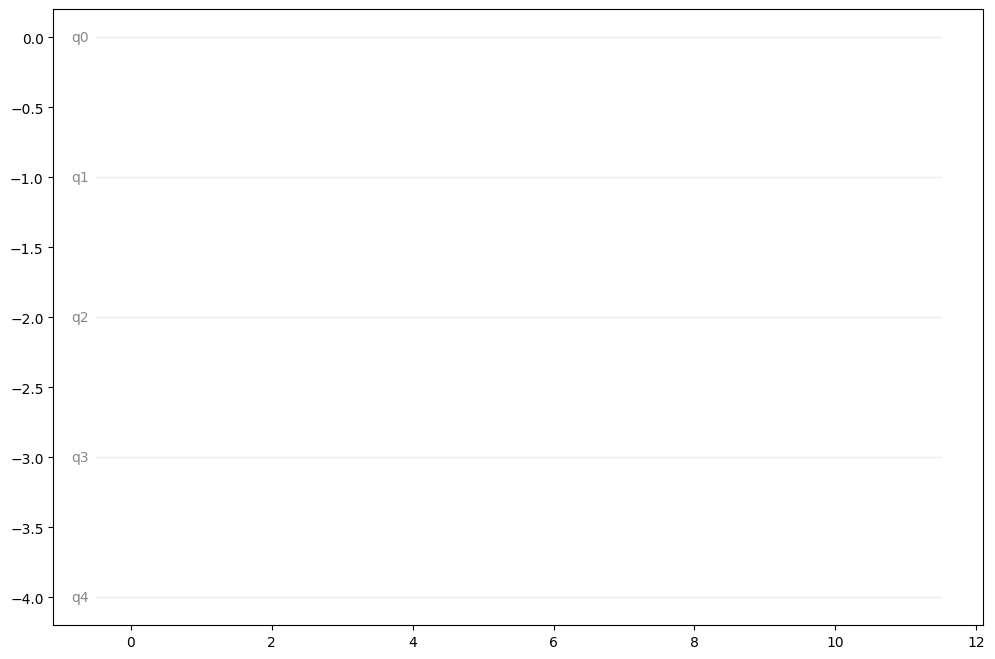

In [18]:
import quimb.tensor as qtn
import cotengra as ctg
import matplotlib.pyplot as plt
import networkx as nx
import math
import warnings
import numpy as np

# Suppress warnings
warnings.filterwarnings("ignore")

def recursive_decompose(circ):
    """Recursively breaks down high-level blocks until we hit basis gates."""
    blockers = ['QAOA', 'PauliEvolution', 'EvolvedOps', 'definition']
    current_circ = circ
    for _ in range(5):
        if any(inst.operation.name in blockers for inst in current_circ.data):
            current_circ = current_circ.decompose()
        else:
            break
    return current_circ

def analyze_and_visualize_combined(qiskit_circ, memory_limit_mb=0.01):
    """
    Combines Qiskit flow visualization with UPMEM Sliced/Rubberband overlay.
    """
    print(f"\n{'='*60}\nANALYZING & VISUALIZING SLICED LAYOUT\n{'='*60}")

    # -----------------------------------------------------
    # 1. DECOMPOSE & SETUP LAYOUT TRACKING
    # -----------------------------------------------------
    decomp_circ = recursive_decompose(qiskit_circ)
    N = decomp_circ.num_qubits
    
    # Layout trackers
    qubit_x_positions = {q: 0.0 for q in range(N)}
    fixed_positions = {} 
    
    # Initialize TN
    tn = qtn.TensorNetwork([])
    wire_frontier = {q: f"q{q}_0" for q in range(N)}
    wire_counters = {q: 0 for q in range(N)}
    
    # Keep track of tensors for Cotengra
    # Cotengra maps tree leaves to integer indices of the input list
    tensor_index = 0

    print("Building Tensor Network with Layout Coordinates...")

    # -----------------------------------------------------
    # 2. BUILD TN & CALCULATE COORDINATES SIMULTANEOUSLY
    # -----------------------------------------------------
    for instruction in decomp_circ.data:
        op = instruction.operation
        name = op.name
        
        # Skip non-unitary
        if name in ['barrier', 'measure', 'reset']: 
            continue

        # Get Qubit Indices
        try:
            qubits = [decomp_circ.find_bit(q).index for q in instruction.qubits]
        except AttributeError:
            qubits = [decomp_circ.qubits.index(q) for q in instruction.qubits]
            
        # --- A. CALCULATE COORDINATES (Time-Flow Logic) ---
        current_max_x = max([qubit_x_positions[q] for q in qubits])
        gate_x = current_max_x + 1.0  # Spacing
        gate_y = -sum(qubits) / len(qubits) # Centered on wires
        
        # Update frontier X for involved qubits
        for q in qubits:
            qubit_x_positions[q] = gate_x

        # --- B. BUILD TENSOR ---
        # Manage indices (wires)
        input_inds = [wire_frontier[q] for q in qubits]
        output_inds = []
        for q in qubits:
            wire_counters[q] += 1
            new_wire = f"q{q}_{wire_counters[q]}"
            output_inds.append(new_wire)
            wire_frontier[q] = new_wire
            
        # Create Dummy Data (Shape is what matters for slicing)
        num_inds = len(input_inds) + len(output_inds)
        
        # Identify tensor by integer index for Cotengra
        T = qtn.Tensor(
            data=np.zeros(tuple([2] * num_inds)), 
            inds=input_inds + output_inds,
            tags={name, f"I{tensor_index}"} 
        )
        
        tn.add_tensor(T)
        
        # --- C. MAP INDEX TO COORDINATE ---
        # Critical: Cotengra trees reference tensors by their integer index in the input list
        fixed_positions[tensor_index] = (gate_x, gate_y)
        
        tensor_index += 1

    # -----------------------------------------------------
    # 3. COTENGRA OPTIMIZATION
    # -----------------------------------------------------
    limit_bytes = memory_limit_mb * 1024 * 1024
    target_log2 = math.log2(limit_bytes / 16) 
    
    inputs = [tuple(t.inds) for t in tn]
    output = tuple(tn.outer_inds())
    size_dict = {i: d for i, d in tn.ind_sizes().items()}
    
    print(f"[Step 3] Optimizing Slicing (Target 2^{target_log2:.1f})...")
    
    opt_upmem = ctg.HyperOptimizer(
        max_repeats=32, 
        progbar=True,
        slicing_opts={'target_size': 2**target_log2} 
    )

    # Search for the path
    tree = opt_upmem.search(inputs, output, size_dict)
    
    max_mem = math.log2(tree.max_size())
    slices = tree.nslices
    
    print(f"-> Max Memory: 2^{max_mem:.1f}")
    print(f"-> Slices: {slices}")

    # -----------------------------------------------------
    # 4. DRAW COMBINED VISUALIZATION
    # -----------------------------------------------------
    print("Drawing Combined Plot...")
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Optional: Draw faint wire lines for reference
    max_x_val = max(p[0] for p in fixed_positions.values())
    for q in range(N):
        # Draw horizontal lines for qubits
        ax.plot([-0.5, max_x_val + 0.5], [-q, -q], color='#eeeeee', zorder=0, lw=1)
        # Label qubits
        ax.text(-0.6, -q, f"q{q}", va='center', ha='right', color='#888888')

    # --- CORRECTED CALL ---
    tree.plot_rubberband(
        tn, 
        pos=fixed_positions,  # <--- CHANGED from 'fix' to 'pos'
        ax=ax,
        edge_scale=1.5,      
        node_scale=1.0,      
        edge_alpha=0.3,      
        node_colormap="tab20c",
        edge_colormap="viridis_r",
        show_tags=False,
    )
    
    ax.set_title(f"Sliced TN on Circuit Layout\nMem Limit: {memory_limit_mb}MB | Slices: {slices}", fontsize=14)
    ax.axis('off')
    
    # Ensure the circuit doesn't look stretched
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

# =========================================================
# RUN
# =========================================================

# Ensure you have your 'circuit' or 'optimized_circuit' object defined from previous steps
analyze_and_visualize_combined(optimized_circuit, memory_limit_mb=0.0003)